In [56]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

In [4]:
df = pd.read_csv(r"C:\Users\riyap\Downloads\processed.cleveland.csv", header=None)

df.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


In [42]:
columns = [ "age","sex","cp","trestbps","chol","fbs",
    "restecg","thalach","exang","oldpeak",
    "slope","ca","thal","target"]

In [43]:
print(df.head())
print(df.shape)

        age  sex   cp  trestbps      chol  fbs  restecg   thalach  exang  \
0  0.936181  1.0  1.0  0.750380 -0.276443  1.0      2.0  0.017494    0.0   
1  1.378929  1.0  4.0  1.596266  0.744555  0.0      2.0 -1.816334    1.0   
2  1.378929  1.0  4.0 -0.659431 -0.353500  0.0      2.0 -0.899420    1.0   
3 -1.941680  1.0  3.0 -0.095506  0.051047  0.0      0.0  1.633010    0.0   
4 -1.498933  0.0  2.0 -0.095506 -0.835103  0.0      2.0  0.978071    0.0   

    oldpeak  slope   ca  thal  target  
0  1.068965    3.0  0.0   6.0       0  
1  0.381773    2.0  3.0   3.0       1  
2  1.326662    2.0  2.0   7.0       1  
3  2.099753    3.0  0.0   3.0       0  
4  0.295874    1.0  0.0   3.0       0  
(297, 14)


In [44]:
print(df.info())
print(df.describe())
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
Index: 297 entries, 0 to 301
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       297 non-null    float64
 1   sex       297 non-null    float64
 2   cp        297 non-null    float64
 3   trestbps  297 non-null    float64
 4   chol      297 non-null    float64
 5   fbs       297 non-null    float64
 6   restecg   297 non-null    float64
 7   thalach   297 non-null    float64
 8   exang     297 non-null    float64
 9   oldpeak   297 non-null    float64
 10  slope     297 non-null    float64
 11  ca        297 non-null    float64
 12  thal      297 non-null    float64
 13  target    297 non-null    int64  
dtypes: float64(13), int64(1)
memory usage: 34.8 KB
None
                age         sex          cp      trestbps          chol  \
count  2.970000e+02  297.000000  297.000000  2.970000e+02  2.970000e+02   
mean  -1.226105e-16    0.676768    3.158249  4.904420e-16 -1.958777e-

In [45]:
df.replace("?", np.nan, inplace=True)

df["ca"] = pd.to_numeric(df["ca"])
df["thal"] = pd.to_numeric(df["thal"])

print(df.isnull().sum())

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


In [46]:
df.fillna(df.median(), inplace=True)

In [47]:
df["target"] = df["target"].apply(lambda x: 1 if x > 0 else 0)

In [48]:
df.drop_duplicates(inplace=True)

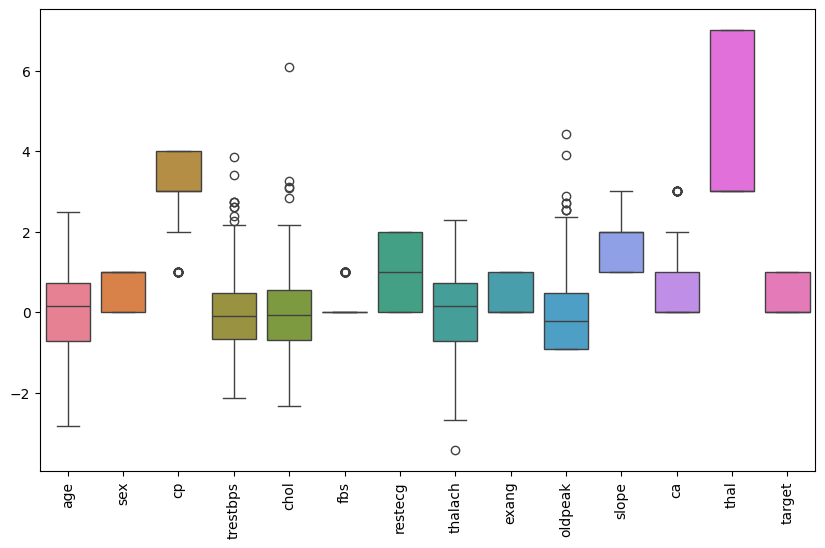

In [50]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df)
plt.xticks(rotation=90)
plt.show()

In [51]:
df = df.clip(lower=df.quantile(0.01), upper=df.quantile(0.99), axis=1)

In [53]:
scaler = StandardScaler()

X = df.drop("target", axis=1)
y = df["target"]

X_scaled = scaler.fit_transform(X)

In [55]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42)

In [57]:
model = LogisticRegression()

model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [58]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.8833333333333333
              precision    recall  f1-score   support

           0       0.91      0.89      0.90        36
           1       0.84      0.88      0.86        24

    accuracy                           0.88        60
   macro avg       0.88      0.88      0.88        60
weighted avg       0.88      0.88      0.88        60

[[32  4]
 [ 3 21]]


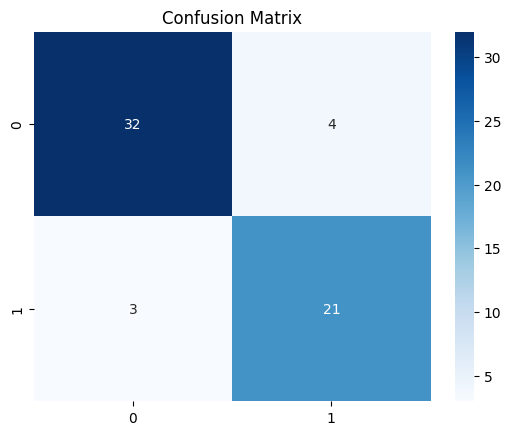

In [59]:
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

In [62]:
def healthcare_agent(patient_data):

    patient_df = pd.DataFrame([patient_data], columns=X.columns)

    print("Original Patient Data:")
    print(patient_df)

    patient_scaled = scaler.transform(patient_df)

    print("\nScaled Patient Data:")
    print(patient_scaled)

    prediction = model.predict(patient_scaled)[0]
    probability = model.predict_proba(patient_scaled)[0]

    print("\nPrediction Value:", prediction)
    print("Prediction Probability:", probability)

    if prediction == 1:
        result = "High risk of heart disease"
    else:
        result = "Low risk of heart disease"

    print("\nFinal Diagnosis:", result)

    return result

In [63]:
patient = [55,1,3,130,250,0,1,150,0,1.5,2,0,3]

healthcare_agent(patient)

Original Patient Data:
   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   55    1   3       130   250    0        1      150      0      1.5      2   

   ca  thal  
0   0     3  

Scaled Patient Data:
[[ 5.60105376e+01  6.91094740e-01 -1.64289475e-01  1.33230962e+02
   2.65197571e+02 -4.11450287e-01  3.38992789e-03  1.52911204e+02
  -6.96419414e-01  1.56689755e+00  6.43781098e-01 -7.21976052e-01
  -8.94220072e-01]]

Prediction Value: 1
Prediction Probability: [0. 1.]

Final Diagnosis: High risk of heart disease


'High risk of heart disease'

In [64]:
y_pred = model.predict(X_test)

results = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})

print(results.head(20))

     Actual  Predicted
169       0          0
214       1          0
63        0          0
155       1          1
5         0          0
77        0          0
185       0          0
159       0          1
9         1          1
140       0          0
290       1          1
78        0          0
93        0          0
102       0          0
42        0          0
225       0          0
288       0          0
33        0          0
267       1          0
149       0          0
